<a href="https://colab.research.google.com/github/JoaoTMLopes/llm-finance-lab/blob/main/sentiment-radar/notebooks/sentiment_radar_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q yfinance python-dotenv

In [2]:
!pip install -q transformers sentencepiece accelerate

In [7]:
!pip install -q --upgrade --no-cache-dir yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 8.3 MB/s eta 0:00:00


In [8]:
import torch
print("GPU disponível:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU disponível: True
Device: Tesla T4


FINBERT_SETENCE_TEST


---



In [9]:
from transformers import pipeline

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert"
)

exemplo = "Apple reported record quarterly revenue, beating analyst expectations."
resultado = finbert(exemplo)
print(resultado)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[{'label': 'positive', 'score': 0.9477707743644714}]


In [10]:
frases = [
    "The company missed earnings estimates and cut its guidance for next year.",
    "Shares remained flat as investors awaited the Fed's decision.",
    "Record profits were driven by strong demand in the semiconductor segment."
]

for frase, res in zip(frases, finbert(frases)):
    print(f"{res['label'].upper():8} ({res['score']:.2f}) — {frase}")

NEGATIVE (0.97) — The company missed earnings estimates and cut its guidance for next year.
NEGATIVE (0.86) — Shares remained flat as investors awaited the Fed's decision.
POSITIVE (0.96) — Record profits were driven by strong demand in the semiconductor segment.


Aplication of Finbert in real data from yahoo finance


In [11]:
import yfinance as yf

def get_headlines(ticker_symbol, max_results=10):
    ticker = yf.Ticker(ticker_symbol)
    try:
        news_items = ticker.news
    except Exception as e:
        print(f"Erro ao obter notícias de {ticker_symbol}: {e}")
        return []

    headlines = []
    for item in news_items[:max_results]:
        content = item.get("content", {})
        title = content.get("title")
        pub_date = content.get("pubDate")
        publisher = content.get("provider", {}).get("displayName", "desconhecido")
        if title:
            headlines.append({
                "ticker": ticker_symbol,
                "title": title,
                "publisher": publisher,
                "published": pub_date
            })
    return headlines

noticias_aapl = get_headlines("AAPL")
for n in noticias_aapl:
    print(n["published"], "-", n["title"])

2026-09-23T11:00:00Z - The hidden tech trap destroying your portfolio
2026-09-22T21:31:33Z - Meta’s Muse just changed the AI game
2026-09-22T17:04:02Z - Meta has 'enormous advantage' in rally sparked by new Muse AI
2026-09-23T13:10:00Z - One of These S&P 500 Funds Has Trailed for 10 Years. Its Fans Say That’s the Point.
2026-09-23T12:49:01Z - Stock Market Today: Nasdaq Dips After Hitting Record Highs; Micron, Sandisk Sink In Buy Zones (Live Coverage)
2026-09-23T11:55:03Z - Apple’s iPhone 18 Demand Improves At The Margin, China Remains Weak Spot, Says UBS — Latest Target Implies 13% Downside Potential
2026-09-23T11:37:00Z - The Stock Market Is Sleeping on the Next Big AI Catalyst
2026-09-23T09:30:00Z - Gadgets Are Going Premium—and Manufacturers Are Raking It In
2026-09-23T07:15:00Z - Muse AI Makes Meta Connect a Must Watch for Investors
2026-09-23T07:00:00Z - OpenAI’s search for a chief communications officer hits 9 months after a top candidate turned down the role


In [12]:
import pandas as pd

def classificar_noticias(headlines, modelo=finbert):
    if not headlines:
        return pd.DataFrame()
    titulos = [h["title"] for h in headlines]
    resultados = modelo(titulos)
    for h, r in zip(headlines, resultados):
        h["sentimento"] = r["label"]
        h["score"] = r["score"]
    return pd.DataFrame(headlines)

df_aapl = classificar_noticias(noticias_aapl)
df_aapl

,ticker,title,publisher,published,sentimento,score
0,AAPL,The hidden tech trap destroying your portfolio,Yahoo Finance Video,2026-09-23T11:00:00Z,negative,0.521387
1,AAPL,Meta’s Muse just changed the AI game,Yahoo Finance Video,2026-09-22T21:31:33Z,neutral,0.878596
2,AAPL,Meta has 'enormous advantage' in rally sparked...,Yahoo Finance Video,2026-09-22T17:04:02Z,positive,0.910131
3,AAPL,One of These S&P 500 Funds Has Trailed for 10 ...,24/7 Wall St.,2026-09-23T13:10:00Z,neutral,0.797784
4,AAPL,Stock Market Today: Nasdaq Dips After Hitting ...,Investor's Business Daily,2026-09-23T12:49:01Z,negative,0.946473
5,AAPL,Apple’s iPhone 18 Demand Improves At The Margi...,Stocktwits,2026-09-23T11:55:03Z,negative,0.894721
6,AAPL,The Stock Market Is Sleeping on the Next Big A...,Barrons.com,2026-09-23T11:37:00Z,neutral,0.731727
7,AAPL,Gadgets Are Going Premium—and Manufacturers Ar...,The Wall Street Journal,2026-09-23T09:30:00Z,neutral,0.729085
8,AAPL,Muse AI Makes Meta Connect a Must Watch for In...,Barrons.com,2026-09-23T07:15:00Z,neutral,0.795011
9,AAPL,OpenAI’s search for a chief communications off...,Fortune,2026-09-23T07:00:00Z,neutral,0.689637


In [13]:
tickers = ["AAPL", "MSFT", "NVDA", "TSLA", "GOOGL"]

todas_noticias = []
for t in tickers:
    todas_noticias.extend(get_headlines(t))

df_geral = classificar_noticias(todas_noticias)
df_geral.head(10)

,ticker,title,publisher,published,sentimento,score
0,AAPL,The hidden tech trap destroying your portfolio,Yahoo Finance Video,2026-09-23T11:00:00Z,negative,0.521387
1,AAPL,Meta’s Muse just changed the AI game,Yahoo Finance Video,2026-09-22T21:31:33Z,neutral,0.878596
2,AAPL,Meta has 'enormous advantage' in rally sparked...,Yahoo Finance Video,2026-09-22T17:04:02Z,positive,0.910131
3,AAPL,One of These S&P 500 Funds Has Trailed for 10 ...,24/7 Wall St.,2026-09-23T13:10:00Z,neutral,0.797784
4,AAPL,Stock Market Today: Nasdaq Dips After Hitting ...,Investor's Business Daily,2026-09-23T12:49:01Z,negative,0.946473
5,AAPL,Apple’s iPhone 18 Demand Improves At The Margi...,Stocktwits,2026-09-23T11:55:03Z,negative,0.894721
6,AAPL,The Stock Market Is Sleeping on the Next Big A...,Barrons.com,2026-09-23T11:37:00Z,neutral,0.731727
7,AAPL,Gadgets Are Going Premium—and Manufacturers Ar...,The Wall Street Journal,2026-09-23T09:30:00Z,neutral,0.729085
8,AAPL,Muse AI Makes Meta Connect a Must Watch for In...,Barrons.com,2026-09-23T07:15:00Z,neutral,0.795011
9,AAPL,OpenAI’s search for a chief communications off...,Fortune,2026-09-23T07:00:00Z,neutral,0.689637


In [14]:
import time

todas_noticias = []
for t in tickers:
    resultado = get_headlines(t)
    print(f"{t}: {len(resultado)} notícias obtidas")
    todas_noticias.extend(resultado)
    time.sleep(2)

df_geral = classificar_noticias(todas_noticias)
print(f"\nTotal de linhas no df_geral: {len(df_geral)}")
df_geral["ticker"].value_counts()

AAPL: 10 notícias obtidas
MSFT: 10 notícias obtidas
NVDA: 10 notícias obtidas
TSLA: 10 notícias obtidas
GOOGL: 10 notícias obtidas

Total de linhas no df_geral: 50


,count
ticker,
AAPL,10
MSFT,10
NVDA,10
TSLA,10
GOOGL,10


In [24]:
def score_numerico(row):
    if row["sentimento"] == "positive":
        return row["score"]
    elif row["sentimento"] == "negative":
        return -row["score"]
    else:
        return 0.0

df_geral["score_sinal"] = df_geral.apply(score_numerico, axis=1)
df_geral["published"] = pd.to_datetime(df_geral["published"])
df_geral["data"] = df_geral["published"].dt.date
agregado = df_geral.groupby(["ticker", "data"])["score_sinal"].mean().reset_index()
agregado.rename(columns={"score_sinal": "sentimento_medio"}, inplace=True)
agregado
precos = yf.download(tickers, period="5d", interval="1d")["Close"]
precos.tail()
import os
from google.colab import drive

drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data", exist_ok=True)

df_geral.to_csv("/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data/noticias_classificadas.csv", index=False)
agregado.to_csv("/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data/sentimento_agregado.csv", index=False)
from google.colab import drive
drive.mount('/content/drive')

os.makedirs("/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data", exist_ok=True)
df_geral.to_csv("/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data/noticias_classificadas.csv", index=False)

/tmp/ipykernel_1561/589266931.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  precos = yf.download(tickers, period="5d", interval="1d")["Close"]
[*********************100%***********************]  5 of 5 completed


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Passagre from the sentiment for the effect on price of stocks

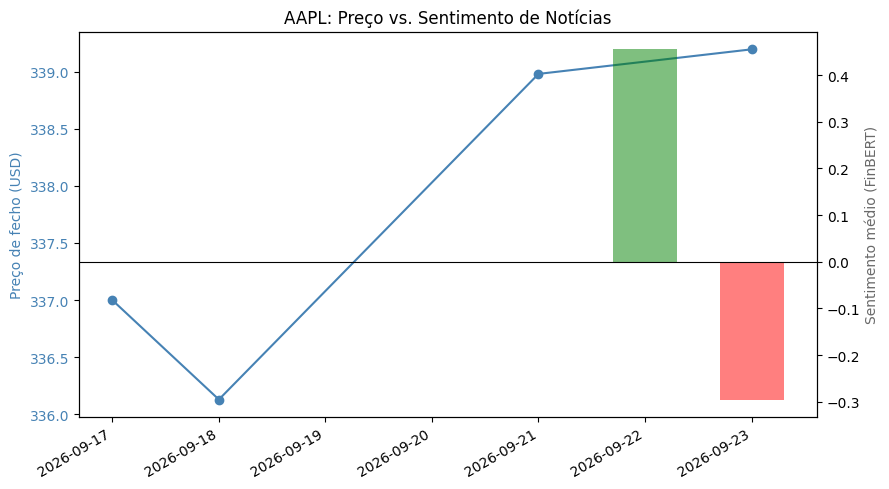

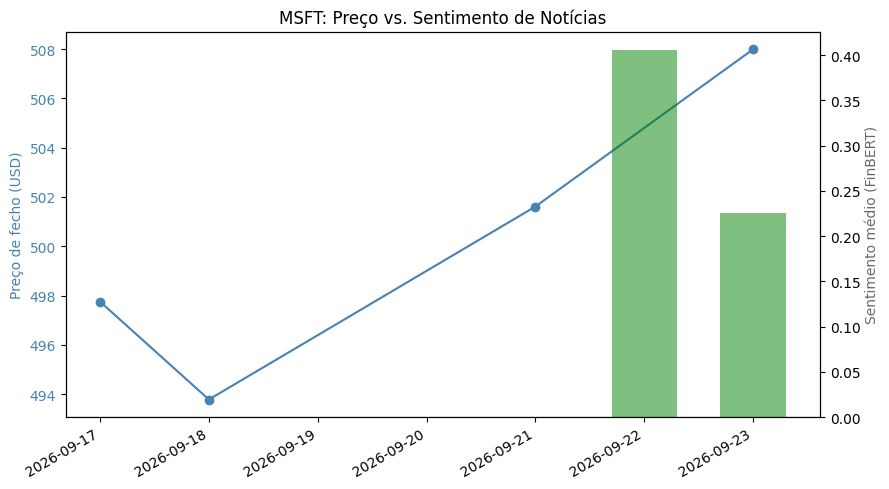

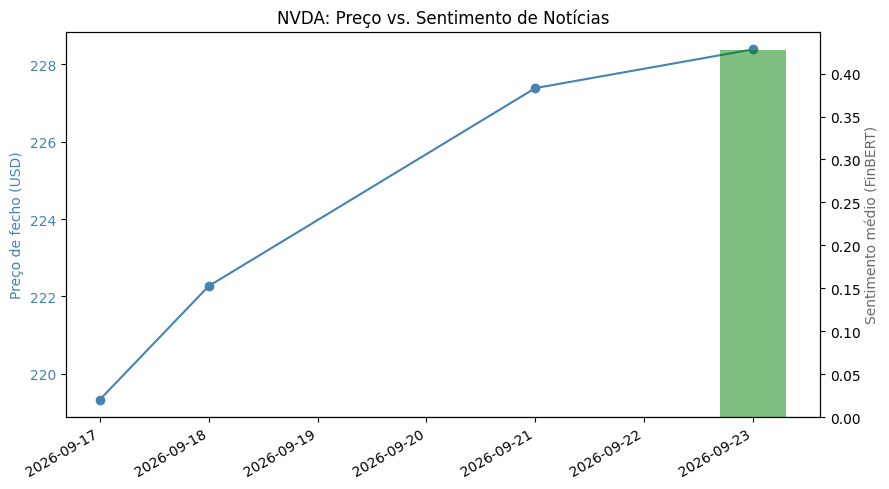

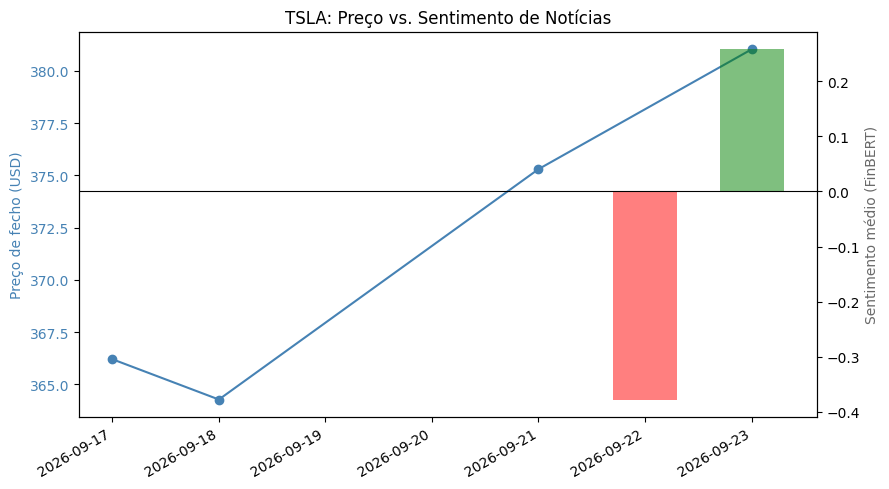

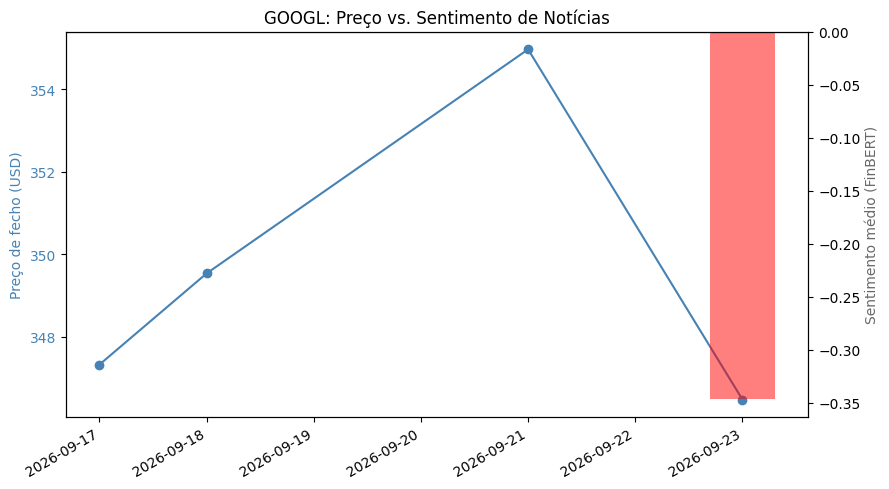

In [26]:
precos_long = precos.reset_index().melt(id_vars="Date", var_name="ticker", value_name="preco_fecho")
precos_long["data"] = pd.to_datetime(precos_long["Date"]).dt.date
precos_long = precos_long[["ticker", "data", "preco_fecho"]]
precos_long.tail(10)
import matplotlib.pyplot as plt

def plot_sentimento_preco(ticker_symbol):
    dados_preco = precos_long[precos_long["ticker"] == ticker_symbol].sort_values("data")
    dados_sent = agregado[agregado["ticker"] == ticker_symbol]

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(dados_preco["data"], dados_preco["preco_fecho"], color="steelblue", marker="o", label="Preço de fecho")
    ax1.set_ylabel("Preço de fecho (USD)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")

    ax2 = ax1.twinx()
    cores = ["green" if s > 0 else "red" if s < 0 else "gray" for s in dados_sent["sentimento_medio"]]
    ax2.bar(dados_sent["data"], dados_sent["sentimento_medio"], color=cores, alpha=0.5, width=0.6, label="Sentimento médio")
    ax2.set_ylabel("Sentimento médio (FinBERT)", color="dimgray")
    ax2.axhline(0, color="black", linewidth=0.8)

    plt.title(f"{ticker_symbol}: Preço vs. Sentimento de Notícias")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data/{ticker_symbol}_sentimento_preco.png", dpi=150)
    plt.show()

for t in tickers:
    plot_sentimento_preco(t)

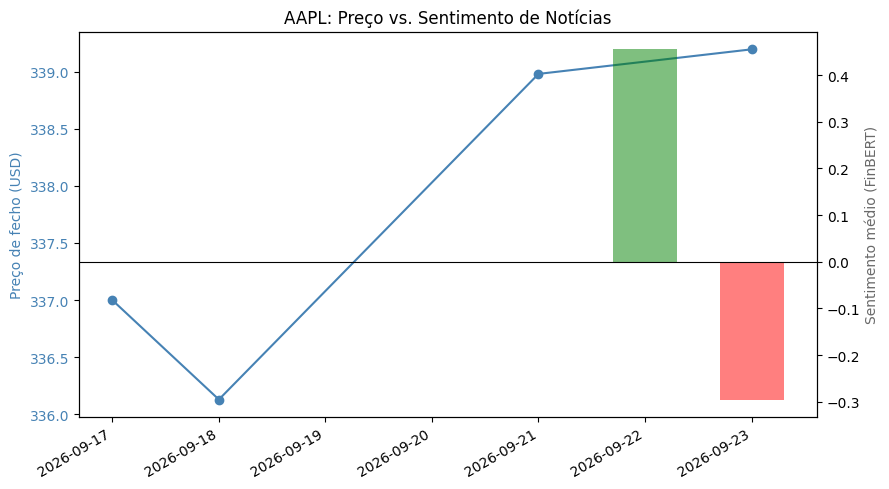

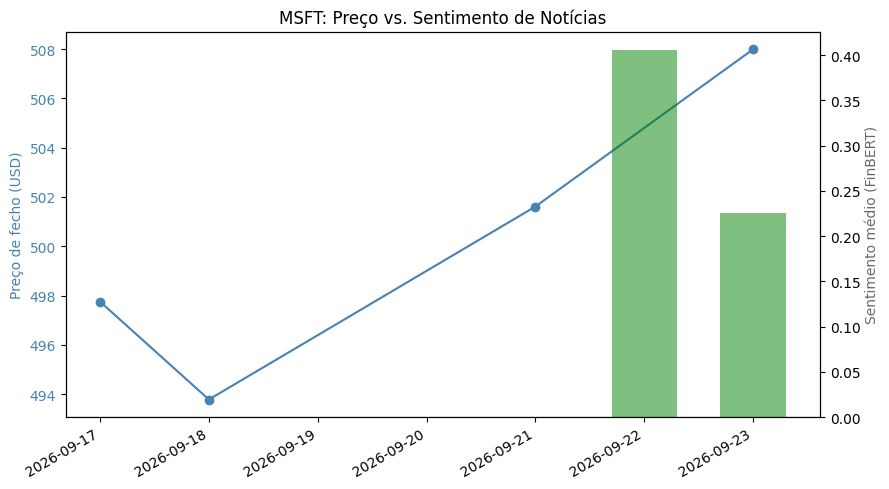

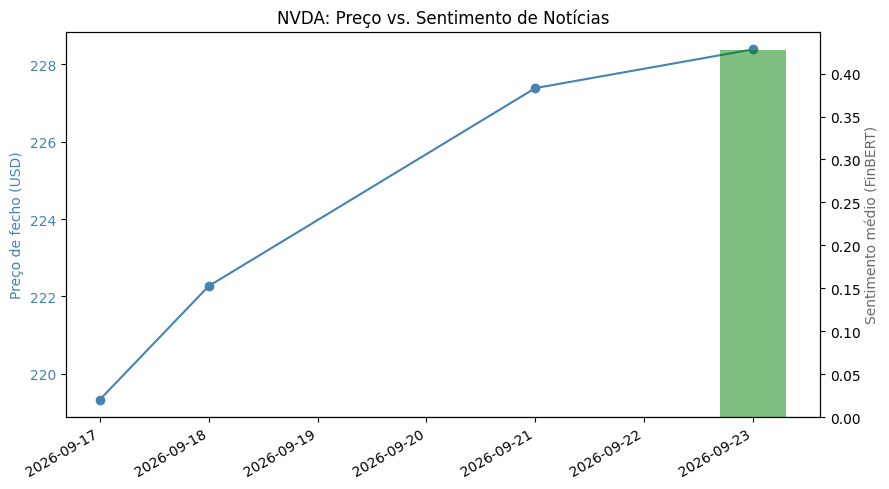

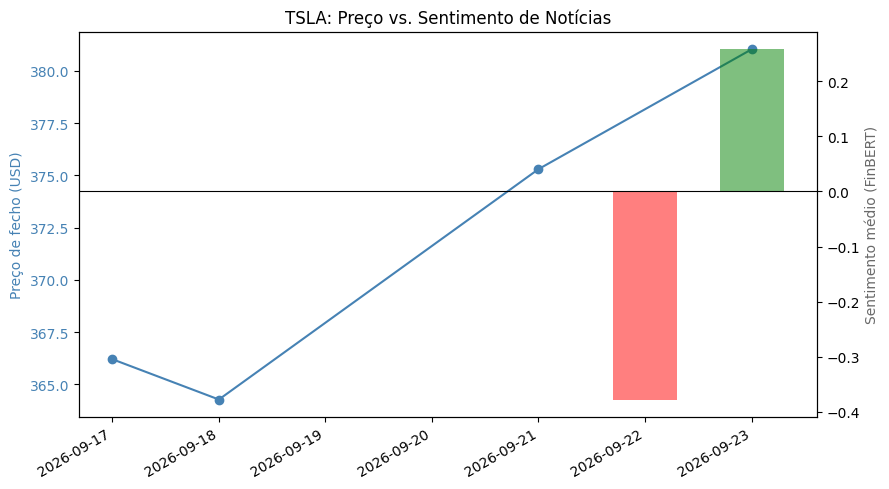

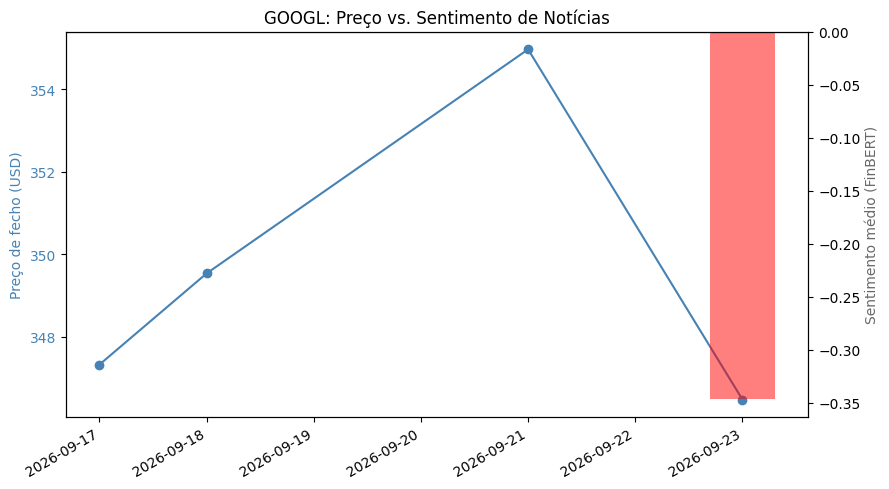

In [27]:
import matplotlib.pyplot as plt

def plot_sentimento_preco(ticker_symbol):
    dados_preco = precos_long[precos_long["ticker"] == ticker_symbol].sort_values("data")
    dados_sent = agregado[agregado["ticker"] == ticker_symbol]

    fig, ax1 = plt.subplots(figsize=(9, 5))

    ax1.plot(dados_preco["data"], dados_preco["preco_fecho"], color="steelblue", marker="o", label="Preço de fecho")
    ax1.set_ylabel("Preço de fecho (USD)", color="steelblue")
    ax1.tick_params(axis="y", labelcolor="steelblue")

    ax2 = ax1.twinx()
    cores = ["green" if s > 0 else "red" if s < 0 else "gray" for s in dados_sent["sentimento_medio"]]
    ax2.bar(dados_sent["data"], dados_sent["sentimento_medio"], color=cores, alpha=0.5, width=0.6, label="Sentimento médio")
    ax2.set_ylabel("Sentimento médio (FinBERT)", color="dimgray")
    ax2.axhline(0, color="black", linewidth=0.8)

    plt.title(f"{ticker_symbol}: Preço vs. Sentimento de Notícias")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data/{ticker_symbol}_sentimento_preco.png", dpi=150)
    plt.show()

for t in tickers:
    plot_sentimento_preco(t)

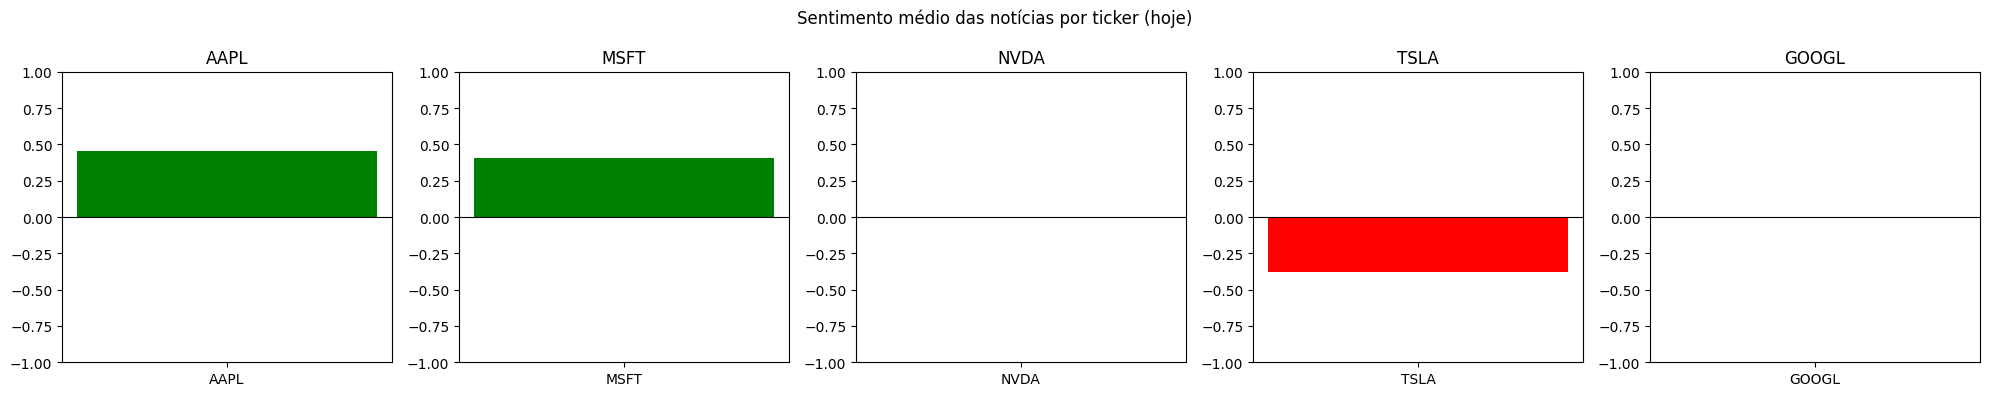

In [30]:
fig, axes = plt.subplots(1, len(tickers), figsize=(4*len(tickers), 4), sharey=False)

for ax, t in zip(axes, tickers):
    linha = agregado[agregado["ticker"] == t]
    if linha.empty:
        ax.text(0.5, 0.5, "sem dados", ha="center", va="center", transform=ax.transAxes, color="gray")
        ax.set_title(t)
        ax.set_ylim(-1, 1)
        continue
    valor = linha["sentimento_medio"].values[0]
    cor = "green" if valor > 0 else "red" if valor < 0 else "gray"
    ax.bar([t], [valor], color=cor)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylim(-1, 1)
    ax.set_title(t)

fig.suptitle("Sentimento médio das notícias por ticker (hoje)")
plt.tight_layout()
plt.show()

In [29]:
agregado[agregado["ticker"].isin(["NVDA", "GOOGL"])]

,ticker,data,sentimento_medio
2,GOOGL,2026-09-22,0.000000
3,GOOGL,2026-09-23,-0.346121
6,NVDA,2026-09-22,0.000000
7,NVDA,2026-09-23,0.427255


Accumulation historical

In [31]:
import os

CAMINHO_HISTORICO = "/content/drive/MyDrive/llm-finance-lab/sentiment-radar/data/historico_noticias.csv"

def guardar_historico(df_novo, caminho=CAMINHO_HISTORICO):
    if os.path.exists(caminho):
        df_existente = pd.read_csv(caminho)
        df_combinado = pd.concat([df_existente, df_novo], ignore_index=True)
        df_combinado.drop_duplicates(subset=["ticker", "title", "published"], inplace=True)
    else:
        df_combinado = df_novo

    df_combinado.to_csv(caminho, index=False)
    print(f"Histórico atualizado: {len(df_combinado)} linhas no total ({len(df_novo)} novas processadas).")
    return df_combinado

df_historico = guardar_historico(df_geral)

Histórico atualizado: 50 linhas no total (50 novas processadas).


In [40]:
!git clone https://github.com/JoaoTMLopes/llm-finance-lab.git

import sys
sys.path.append("/content/llm-finance-lab/src")
from pipeline import carregar_modelo, coletar_e_classificar, guardar_historico

fatal: destination path 'llm-finance-lab' already exists and is not an empty directory.


In [39]:
%cd /content/llm-finance-lab
!git pull
%cd /content

/content/llm-finance-lab
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1018 bytes | 1018.00 KiB/s, done.
From https://github.com/JoaoTMLopes/llm-finance-lab
   e1f3f9f..4b5aeab  main       -> origin/main
Updating e1f3f9f..4b5aeab
Fast-forward
 src/pipeline.py | 3 ---
 1 file changed, 3 deletions(-)
/content


In [41]:
import importlib
import pipeline
importlib.reload(pipeline)  # garante que usa a versão atualizada do ficheiro
from pipeline import carregar_modelo, coletar_e_classificar, guardar_historico

modelo = carregar_modelo()
df_hoje = coletar_e_classificar(tickers, modelo)
df_historico = guardar_historico(df_hoje, CAMINHO_HISTORICO)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]